Importamos las librerias


In [2]:
from qiskit import QuantumCircuit
from qiskit._accelerate import results
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib

pi = np.pi

{'1': 5000}


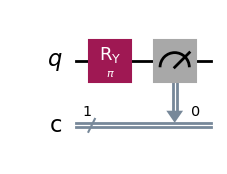

In [2]:
theta = [0, pi/3, pi/2, pi]
shots = 5000

sim = AerSimulator()
qc = QuantumCircuit(1, 1)
qc.ry(theta[3], 0)
qc.measure(0, 0)
job = sim.run(qc, shots=shots)
result = job.result()
counts = result.get_counts(qc)

print(counts)

qc.draw(output="mpl",filename="circ1qb.svg")

{'1': 993, '0': 1007}


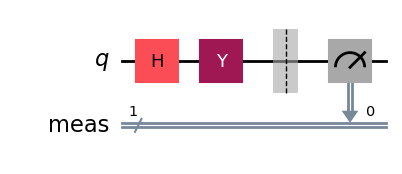

In [3]:
shots = 2000

sim = AerSimulator()
qc = QuantumCircuit(1, 0)

qc.h(0)
qc.y(0)
#qc.cx(0,1)

qc.measure_all()

job = sim.run(qc, shots=shots)

result = job.result()
counts = result.get_counts(qc)

print(counts)

qc.draw(output="mpl")

{'11': 961, '00': 1039}


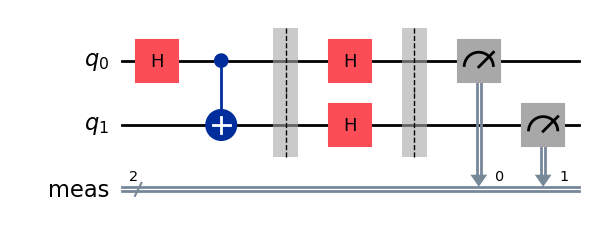

In [3]:
shots = 2000

sim = AerSimulator()
qc = QuantumCircuit(2, 0)

qc.h(0)
qc.cx(0,1)

qc.barrier()

qc.h(0)
qc.h(1)

qc.measure_all()

job = sim.run(qc, shots=shots)

result = job.result()
counts = result.get_counts(qc)

print(counts)

qc.draw(output="mpl",filename="circ2qbXX.svg")

{'01': 484, '11': 498, '10': 498, '00': 520}


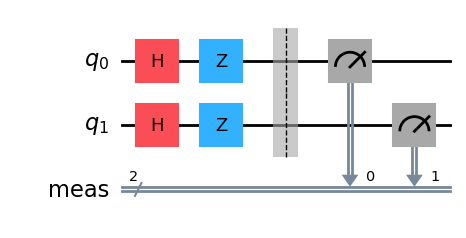

In [5]:
shots = 2000

sim = AerSimulator()
qc = QuantumCircuit(2, 0)

qc.h(0)
qc.h(1)
qc.z(0)
qc.z(1)

qc.measure_all()

job = sim.run(qc, shots=shots)

result = job.result()
counts = result.get_counts(qc)

print(counts)

qc.draw(output="mpl")

{'100': 234, '101': 262, '111': 232, '110': 272}


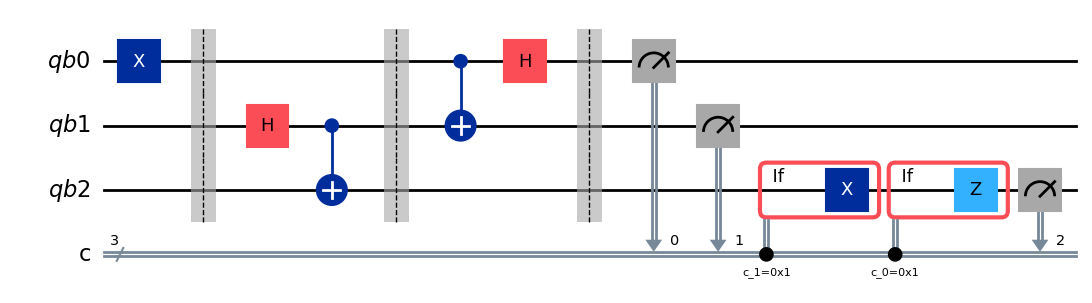

In [4]:
# Step 1: Map your problem to a quantum circuit

# Import some general packages
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
import numpy as np

# Define registers
qb0 = QuantumRegister(1, "qb0")
qb1 = QuantumRegister(1, "qb1")
qb2 = QuantumRegister(1, "qb2")

cr = ClassicalRegister(3, "c")

qc = QuantumCircuit(qb0,qb1,qb2, cr)

# We entangle Alice's and Bob's qubits as in our work above. We apply a Hadamard gate and then a CNOT gate.
# Note that the second argument in the CNOT gate is the target.

qc.x(qb0)


# Inserting a barrier changes nothing about the logic. It just allows us to force gates to be positioned in "layers".
qc.barrier()
qc.h(qb1)
qc.cx(qb1, qb2)

# Assign the secret state to the qubit on the other side of Alice's (qubit 0), labeled Q
#qc.u(theta, varphi, 0.0, qb0)
qc.barrier()

# Now entangle Q and Alice's qubits as in the discussion above.
qc.cx(qb0, qb1)
qc.h(qb0)
qc.barrier()

# Now Alice measures her qubits, and stores the outcomes in the "classical registers" cr[]
qc.measure(qb0, cr[0])
qc.measure(qb1, cr[1])



# Now we insert some conditional logic. If Alice measures Q in a "1" we need a Z gate, and if Alice measures A in a "1" we need an X gate (see the table).
with qc.if_test((cr[1], 1)):
	qc.x(qb2)
with qc.if_test((cr[0], 1)): 
	qc.z(qb2)

qc.measure(qb2, cr[2])

job = sim.run(qc, shots=1000)

counts = job.result().get_counts()

print(counts)

qc.draw(output="mpl", filename="circ3qb.svg")